In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from sklearn.svm import SVC
from sklearn import datasets
iris = datasets.load_iris()
x =  iris["data"]
y = iris["target"]

setosa_or_versicolor = (y == 0) | (y == 1)
x = x[setosa_or_versicolor]
y = y[setosa_or_versicolor]

<function matplotlib.pyplot.show(close=None, block=None)>

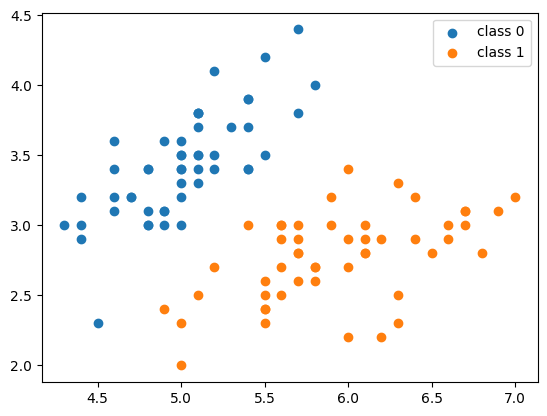

In [ ]:
plt.scatter(x[:,0] [y==0],x[:,1] [y==0], label ="class 0")
plt.scatter(x[:,0] [y==1],x[:,1] [y==1], label ="class 1")
plt.legend()
plt.show

In [ ]:
svm_clf = SVC(kernel = "linear", C = float("inf"))
svm_clf.fit(x,y)

SVC(C=inf, kernel='linear')

In [ ]:
svm_clf.coef_

array([[ 0.04625854, -0.5211828 ,  1.00304462,  0.46412978]])

In [ ]:
svm_clf.intercept_

array([-1.4528445])

In [ ]:
def plot_svc_decision_boundary(svm_clf,xmin,xmax):
  w = svm_clf.coef_[0]
  b = svm_clf.intercept_[0]

  x0 = np.linspace(xmin,xmax,200)
  decision_boundary = -w[0]/w[1]* x0 - b/w[1]

  margin = 1/w[1]
  gutter_up = decision_boundary + margin
  gutter_down = decision_boundary - margin

  svs = svm_clf.support_vectors_
  plt.plot(x0, decision_boundary, "k-", linewidth =2, label = "Hyperplane")
  plt.plot(x0, gutter_up, "k--", linewidth=1)
  plt.plot(x0, gutter_down, "k--", linewidth=1)
  plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#FFAAAA', label = "Support vectors")

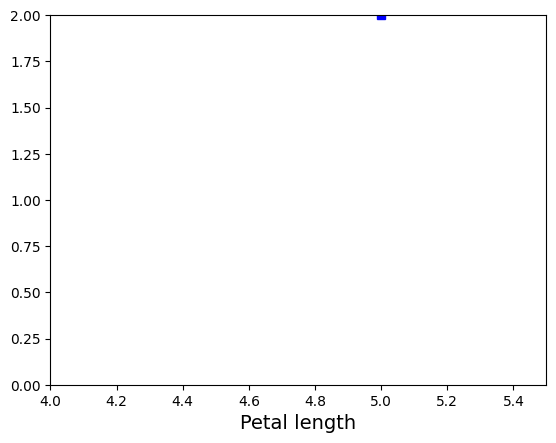

In [ ]:
plot_svc_decision_boundary(svm_clf, 4, 5.5)

plt.plot(x[:, 0][y == 1], x[:, 1][y == 1], "bs")
plt.plot(x[:, 0][y == 0], x[:, 1][y == 0], "yo")

plt.xlabel("Petal length", fontsize=14)
plt.axis([4, 5.5, 0, 2])
plt.show()

In [ ]:
svm_clf.support_vectors_

array([[5.1, 3.3, 1.7, 0.5],
       [4.5, 2.3, 1.3, 0.3],
       [5.1, 2.5, 3. , 1.1]])

(np.float64(0.0), np.float64(6.0), np.float64(0.0), np.float64(90.0))

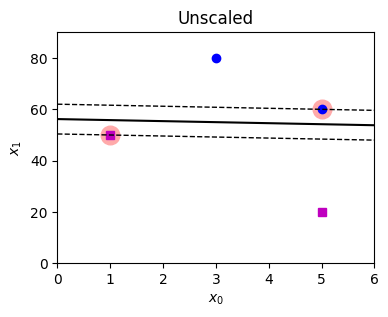

In [ ]:
Xs = np.array([[1, 50], [5, 20], [3, 80], [5, 60]]).astype(np.float64)
ys = np.array([0, 0, 1, 1])
svm_clf = SVC(kernel="linear", C=100)
svm_clf.fit(Xs, ys)

plt.figure(figsize=(9,3))
plt.subplot(121)
plt.plot(Xs[:,0][ys==1], Xs[:,1][ys==1], "bo")
plt.plot(Xs[:,0][ys==0], Xs[:,1][ys==0], "ms")
plot_svc_decision_boundary(svm_clf, 0, 6)
plt.xlabel("$x_0$")
plt.ylabel("$x_1$")
plt.title("Unscaled")
plt.axis([0, 6, 0, 90])


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

Xs = np.array([[1, 50], [5, 20], [3, 80], [5, 60]]).astype(np.float64)
ys = np.array([0, 0, 1, 1])

# Pipeline: Scaling + SVM
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf_pipe", SVC(kernel="linear", C=100))
])

# Train
svm_pipe.fit(Xs, ys)

# Access the SVM model inside pipeline
svm_model = svm_pipe["svm_clf_pipe"]
print(svm_model)

SVC(C=100, kernel='linear')
